# Interpretabilidad y evaluación final en el test

Los notebooks anteriores seleccionaron CatBoost con score, ventana de 17 días y features base, sin calibración, mezcla ni segmentación.

En este notebook interpreto el modelo con SHAP y lo evalúo una sola vez sobre la semana de test bloqueada, junto con la regresión logística y aprobar todo como referencias. Los resultados del test se consultan únicamente en la sección 4.

## 1. Setup

In [1]:
from pathlib import Path
import importlib
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import Pool
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (8, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["grid.alpha"] = 0.3

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.features as features_module
import src.modeling as modeling_module
importlib.reload(features_module)
importlib.reload(modeling_module)

from src.business import ganancia_total, umbral_aprobacion
from src.data import TARGET, DEFAULT_DATA_PATH, DEFAULT_PROCESSED_DIR, cargar_datos, convertir_fecha
from src.evaluation import metricas_decision, metricas_probabilidad, obtener_params
from src.features import crear_features_arbol, crear_features_logistica, CATEGORICAS_ARBOL
from src.modeling import ajustar_arbol, ajustar_y_predecir_arbol, crear_pipeline_logistica
from src.validation import TEST_START, TEST_END, mascaras_desarrollo_test

UMBRAL_ECONOMICO = umbral_aprobacion()
SEMILLAS = [42, 43, 44]
DIAS_VENTANA = 17
PARAMS_PATH = DEFAULT_PROCESSED_DIR / "mejores_params_arbol.json"

print(f"Umbral económico: {UMBRAL_ECONOMICO:.2f}")
print(f"Test bloqueado: {TEST_START.date()} a {(TEST_END - pd.Timedelta(days=1)).date()}")

Umbral económico: 0.20
Test bloqueado: 2020-04-15 a 2020-04-21


In [2]:
df = cargar_datos(DEFAULT_DATA_PATH)
fecha = convertir_fecha(df["fecha"])
fecha_origen = fecha.min().normalize()
y = df[TARGET]
monto = df["monto"]

with PARAMS_PATH.open(encoding="utf-8") as archivo:
    params_guardados = json.load(archivo)
PARAMS_CATBOOST = obtener_params(params_guardados, "catboost", "con_score", 3)

X_arbol = crear_features_arbol(df, incluir_score=True, fecha_origen=fecha_origen)
X_logistica = crear_features_logistica(df, incluir_score=True, fecha_origen=fecha_origen)

# Máscaras temporales. El test queda intacto hasta la sección 4.
es_desarrollo, es_test = mascaras_desarrollo_test(fecha)
ventana_inicio = TEST_START - pd.Timedelta(days=DIAS_VENTANA)
mascara_train_ventana = (fecha >= ventana_inicio) & (fecha < TEST_START)
mascara_train_acumulado = fecha < TEST_START

assert not (mascara_train_ventana & es_test).any()
assert not (mascara_train_acumulado & es_test).any()

print(f"Train ventana ({ventana_inicio.date()} a {TEST_START.date()}): "
      f"{mascara_train_ventana.sum():,} filas, {int(y.loc[mascara_train_ventana].sum()):,} fraudes")
print(f"Train acumulado (desde {fecha.min().date()}): "
      f"{mascara_train_acumulado.sum():,} filas, {int(y.loc[mascara_train_acumulado].sum()):,} fraudes")
print(f"Test: {int(es_test.sum()):,} filas, {int(y.loc[es_test].sum()):,} fraudes "
      f"({y.loc[es_test].mean():.1%} de fraude)")
print("Params CatBoost final:", PARAMS_CATBOOST)

Train ventana (2020-03-29 a 2020-04-15): 50,348 filas, 2,792 fraudes
Train acumulado (desde 2020-03-08): 121,014 filas, 6,262 fraudes
Test: 28,986 filas, 1,238 fraudes (4.3% de fraude)
Params CatBoost final: {'iterations': 476, 'depth': 8, 'learning_rate': 0.045450180574436616, 'l2_leaf_reg': 2.585003944937531}


## 2. Qué quedó congelado

Todas las decisiones se tomaron sobre desarrollo:

- **Modelo:** CatBoost con score y los hiperparámetros elegidos en el notebook 4.
- **Historia:** ventana de 17 días como opción seleccionada y acumulado como comparación. El test no interviene en esta elección.
- **Features:** conjunto base, sin calibración, mezcla ni modelos por segmento, ya que esas variantes no mejoraron de forma estable.

Las referencias son la regresión logística con score y aprobar todo.

## 3. Interpretabilidad con SHAP

SHAP reparte la predicción de cada operación entre sus features: cuánto empuja cada una hacia fraude o hacia legítima. Sumadas, explican por qué el modelo dio esa probabilidad. Uso la implementación nativa de CatBoost, que es exacta para árboles.

Entreno el CatBoost final sobre la ventana de 17 días y calculo SHAP sobre una muestra de ese mismo train. Esto describe cómo decide el modelo usando solamente desarrollo, sin consultar etiquetas ni resultados del test.

In [3]:
modelo_shap, train_preparado, _ = ajustar_arbol(
    "catboost", PARAMS_CATBOOST,
    X_arbol.loc[mascara_train_ventana], y.loc[mascara_train_ventana],
    X_arbol.loc[es_test], semilla=42,
)

muestra = train_preparado.sample(min(3000, len(train_preparado)), random_state=42)
valores_shap = modelo_shap.get_feature_importance(
    Pool(muestra, cat_features=CATEGORICAS_ARBOL), type="ShapValues"
)
shap_matriz = valores_shap[:, :-1]
valor_base = valores_shap[0, -1]

importancia = (
    pd.Series(np.abs(shap_matriz).mean(axis=0), index=train_preparado.columns)
    .sort_values(ascending=False)
)
print(f"Valor base del modelo (log-odds): {valor_base:.3f}")
importancia.head(12)

Valor base del modelo (log-odds): -4.095


o                   0.7951
score               0.7556
monto               0.2391
l                   0.1911
m                   0.1664
g                   0.1082
d                   0.0910
hora                0.0818
f                   0.0775
j                   0.0729
c                   0.0585
dias_desde_inicio   0.0540
dtype: float64

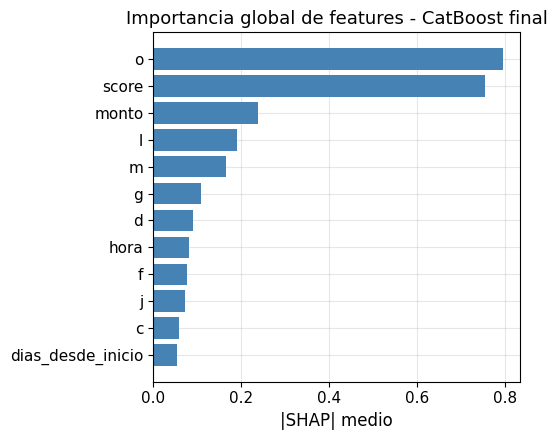

In [4]:
top = importancia.head(12)[::-1]
fig, ax = plt.subplots(figsize=(5.4, 4.5))
ax.barh(top.index, top.values, color="steelblue")
ax.set_xlabel("|SHAP| medio", fontsize=12)
ax.set_title("Importancia global de features - CatBoost final", fontsize=13)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

**o y score son las señales más fuertes**, seguidas por monto. Esto coincide con el EDA, donde la ausencia de o y los valores altos de score ya mostraban una relación clara con el fraude.

j tiene menos peso que en la regresión logística. CatBoost procesa esta variable categórica mediante estadísticas de target, por lo que distribuye su aporte de otra manera. En general, las variables principales coinciden con los patrones observados en el EDA.

In [5]:
# Casos locales sobre desarrollo: un fraude de monto alto y un caso borde cerca del umbral.
prob_train = pd.Series(
    modelo_shap.predict_proba(Pool(train_preparado, cat_features=CATEGORICAS_ARBOL))[:, 1],
    index=train_preparado.index,
)
y_ventana = y.loc[mascara_train_ventana]
monto_ventana = monto.loc[mascara_train_ventana]

idx_fraude = monto_ventana[y_ventana.eq(1)].idxmax()
idx_borde = (prob_train - UMBRAL_ECONOMICO).abs().idxmin()
casos = {"fraude de monto alto": idx_fraude, "caso borde (~20%)": idx_borde}

filas_local = train_preparado.loc[list(casos.values())]
shap_local = modelo_shap.get_feature_importance(
    Pool(filas_local, cat_features=CATEGORICAS_ARBOL), type="ShapValues"
)

for etiqueta, idx in casos.items():
    print(f"{etiqueta}: monto={monto.loc[idx]:,.0f}  "
          f"fraude_real={int(y.loc[idx])}  prob_modelo={prob_train.loc[idx]:.3f}")

fraude de monto alto: monto=2,706  fraude_real=1  prob_modelo=0.893
caso borde (~20%): monto=65  fraude_real=1  prob_modelo=0.200


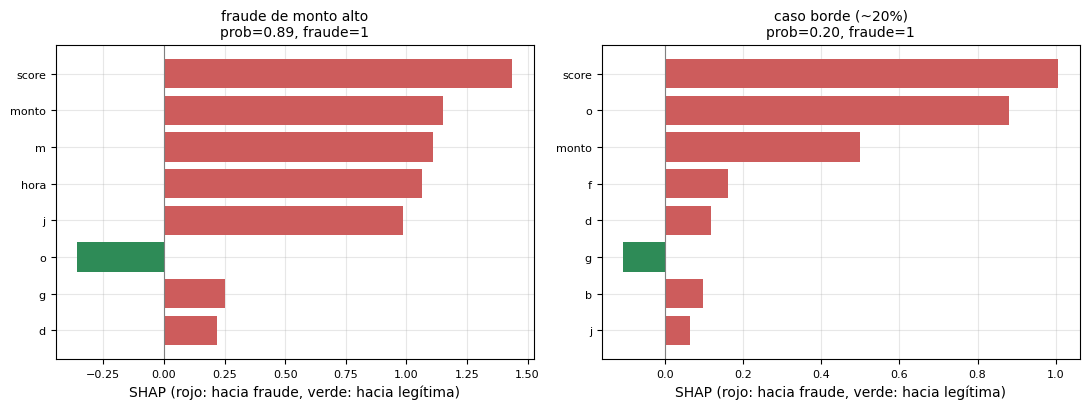

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (etiqueta, idx), fila_shap in zip(axes, casos.items(), shap_local):
    contribs = pd.Series(fila_shap[:-1], index=train_preparado.columns)
    top_contribs = contribs.reindex(contribs.abs().sort_values().index).tail(8)
    colores = np.where(top_contribs.values > 0, "indianred", "seagreen")
    ax.barh(top_contribs.index, top_contribs.values, color=colores)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_title(f"{etiqueta}\nprob={prob_train.loc[idx]:.2f}, fraude={int(y.loc[idx])}", fontsize=10)
    ax.set_xlabel("SHAP (rojo: hacia fraude, verde: hacia legítima)")
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

En el fraude de monto alto, las features de riesgo llevan la probabilidad por encima del umbral y la operación se rechaza. En el caso borde, los aportes a favor y en contra casi se compensan, dejando la probabilidad cerca del 20%. En estas operaciones la decisión es más sensible al umbral.

La interpretación local coincide con la global: o, score y monto concentran los principales aportes.

### 3.1. La forma de score y su interacción con o

La importancia global no muestra la forma del efecto. Por eso grafico la contribución SHAP de score según su valor y uso o como color para observar la interacción `score × o` identificada en el EDA.

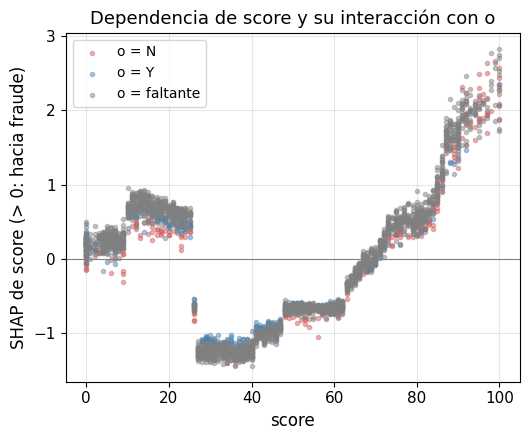

In [7]:
indice_score = list(train_preparado.columns).index("score")
shap_score = shap_matriz[:, indice_score]
score_muestra = muestra["score"].to_numpy()
o_muestra = muestra["o"].astype(str).to_numpy()

fig, ax = plt.subplots(figsize=(5.4, 4.5))
colores_o = {"N": "indianred", "Y": "steelblue", "faltante": "gray"}
for nivel, color in colores_o.items():
    m = o_muestra == nivel
    ax.scatter(score_muestra[m], shap_score[m], s=9, alpha=0.45,
               color=color, label=f"o = {nivel}")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("score", fontsize=12)
ax.set_ylabel("SHAP de score (> 0: hacia fraude)", fontsize=12)
ax.set_title("Dependencia de score y su interacción con o", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

score aporta poco en valores bajos y empuja con fuerza hacia fraude en valores altos. Para un mismo score, las operaciones con `o = N` reciben una contribución mayor que las de `o = Y` o con o faltante. El modelo utiliza ambas variables de forma combinada, en línea con lo observado en el EDA.

## 4. Evaluación final en test

Uso la semana bloqueada una sola vez. Entreno el CatBoost final sobre la ventana y sobre el acumulado, con tres semillas cada uno para no depender de una sola corrida, y predigo sobre el test. Comparo contra la regresión logística con score y contra aprobar todo. El umbral sigue fijo en 20%.

In [8]:
y_test = y.loc[es_test]
monto_test = monto.loc[es_test]
resultados_test = []
probabilidades_test = {}

for nombre, mascara_train in [
    ("catboost_ventana", mascara_train_ventana),
    ("catboost_acumulado", mascara_train_acumulado),
]:
    probas_semillas = []
    ganancias_semillas = []
    for semilla in SEMILLAS:
        proba = ajustar_y_predecir_arbol(
            "catboost", PARAMS_CATBOOST,
            X_arbol.loc[mascara_train], y.loc[mascara_train],
            X_arbol.loc[es_test], semilla=semilla,
        )
        probas_semillas.append(proba)
        ganancias_semillas.append(
            ganancia_total(y_test, monto_test, proba < UMBRAL_ECONOMICO)
        )
    proba_media = pd.concat(probas_semillas, axis=1).mean(axis=1)
    probabilidades_test[nombre] = proba_media
    fila = {
        "modelo": nombre,
        "ganancia": float(np.mean(ganancias_semillas)),
        "variacion_semillas": float(np.std(ganancias_semillas, ddof=1)),
    }
    fila.update(metricas_decision(y_test, monto_test, proba_media < UMBRAL_ECONOMICO))
    fila.update(metricas_probabilidad(y_test, proba_media))
    resultados_test.append(fila)

# Referencia logística (determinística) entrenada sobre la ventana.
pipe_log = crear_pipeline_logistica(incluir_score=True, semilla=SEMILLAS[0])
pipe_log.fit(X_logistica.loc[mascara_train_ventana], y.loc[mascara_train_ventana])
proba_log = pd.Series(
    pipe_log.predict_proba(X_logistica.loc[es_test])[:, 1], index=y_test.index
)
probabilidades_test["logistica_ventana"] = proba_log
fila_log = {"modelo": "logistica_ventana",
            "ganancia": ganancia_total(y_test, monto_test, proba_log < UMBRAL_ECONOMICO),
            "variacion_semillas": 0.0}
fila_log.update(metricas_decision(y_test, monto_test, proba_log < UMBRAL_ECONOMICO))
fila_log.update(metricas_probabilidad(y_test, proba_log))
resultados_test.append(fila_log)

# Piso de negocio: aprobar todo.
aprobar_todo = pd.Series(True, index=y_test.index)
fila_base = {"modelo": "aprobar_todo",
             "ganancia": ganancia_total(y_test, monto_test, aprobar_todo),
             "variacion_semillas": 0.0}
fila_base.update(metricas_decision(y_test, monto_test, aprobar_todo))
resultados_test.append(fila_base)

resultados_test = pd.DataFrame(resultados_test).sort_values("ganancia", ascending=False)
resultados_test

,modelo,ganancia,variacion_semillas,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill
1,catboost_acumulado,"227,914.0925","1,506.0800",0.9550,0.4596,0.0265,0.8872,0.4339,0.0307,0.0427,0.4087,0.2485
0,catboost_ventana,"223,882.3475",893.1690,0.9588,0.4265,0.0240,0.8832,0.4255,0.0310,0.0427,0.3998,0.2422
2,logistica_ventana,"218,834.7325",0.0000,0.9483,0.4111,0.0356,0.8381,0.3265,0.0340,0.0427,0.2965,0.1685
3,aprobar_todo,"191,247.2150",0.0000,1.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN


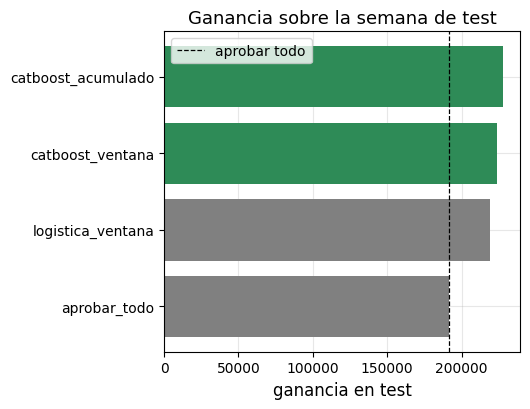

In [9]:
orden = resultados_test.set_index("modelo")["ganancia"].sort_values()
ganancia_piso = resultados_test.set_index("modelo").loc["aprobar_todo", "ganancia"]
colores = ["seagreen" if "catboost" in m else "gray" for m in orden.index]
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.barh(orden.index, orden.values, color=colores)
ax.axvline(ganancia_piso, ls="--", color="black", linewidth=0.9, label="aprobar todo")
ax.set_xlabel("ganancia en test", fontsize=12)
ax.set_title("Ganancia sobre la semana de test", fontsize=13)
ax.tick_params(labelsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

En la semana de test, CatBoost obtiene alrededor de 224.000 con la ventana y 228.000 con el acumulado, frente a 218.835 de la regresión logística y 191.247 de aprobar todo.

El acumulado supera levemente a la ventana en test, pero esta diferencia no modifica la elección realizada en desarrollo. CatBoost también mejora el PR-AUC y el Brier frente a la logística. Estas métricas se reportan sin normalizar porque todos los modelos se evalúan sobre el mismo test y con la misma prevalencia.

### 4.1. Qué tan lejos del máximo posible

El EDA planteaba un techo: la ganancia de un detector perfecto que aprobara solo las operaciones legítimas y rechazara todos los fraudes. Calculo ese máximo sobre el test para ubicar nuestro resultado. La diferencia entre aprobar todo y ese máximo es exactamente el monto total de los fraudes, es decir, la pérdida que un modelo perfecto evitaría.

In [10]:
ganancia_maxima = ganancia_total(y_test, monto_test, y_test.eq(0))  # aprobar solo legítimas
ganancia_piso = resultados_test.set_index("modelo").loc["aprobar_todo", "ganancia"]
margen_capturable = ganancia_maxima - ganancia_piso  # = monto total de los fraudes

resumen_techo = []
for modelo in ["catboost_acumulado", "catboost_ventana", "logistica_ventana", "aprobar_todo"]:
    g = resultados_test.set_index("modelo").loc[modelo, "ganancia"]
    resumen_techo.append({
        "modelo": modelo,
        "ganancia": g,
        "pct_del_maximo": g / ganancia_maxima,
        "pct_margen_capturado": (g - ganancia_piso) / margen_capturable,
    })
resumen_techo = pd.DataFrame(resumen_techo)

print(f"Máximo posible en test (oráculo, solo legítimas): {ganancia_maxima:,.0f}")
print(f"Margen capturable (oráculo - aprobar todo = monto de fraudes): {margen_capturable:,.0f}")
resumen_techo

Máximo posible en test (oráculo, solo legítimas): 284,827
Margen capturable (oráculo - aprobar todo = monto de fraudes): 93,580


,modelo,ganancia,pct_del_maximo,pct_margen_capturado
0,catboost_acumulado,"227,914.0925",0.8002,0.3918
1,catboost_ventana,"223,882.3475",0.7860,0.3487
2,logistica_ventana,"218,834.7325",0.7683,0.2948
3,aprobar_todo,"191,247.2150",0.6714,0.0000


CatBoost queda por encima de aprobar todo y de la regresión logística, aunque todavía existe una diferencia importante respecto del máximo teórico. Este máximo funciona como referencia y no como un resultado alcanzable, ya que supone conocer perfectamente qué operaciones son fraudulentas.

Parte de la diferencia se explica por los fraudes que el modelo todavía aprueba. Además, el dataset no incluye historial de comportamiento por usuario o entidad, que podría aportar señales relevantes para mejorar la detección.

## 5. Calibración en el test

El umbral de 20% solo tiene sentido económico si una probabilidad de 20% significa de verdad ese riesgo. Reviso la calibración del CatBoost final sobre el test: agrupo las predicciones en deciles y comparo la probabilidad media contra el fraude observado.

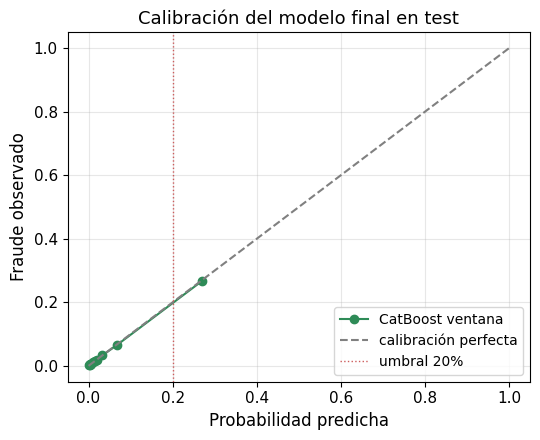

In [11]:
proba_final = probabilidades_test["catboost_ventana"]
observado, predicho = calibration_curve(
    y_test, proba_final, n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(predicho, observado, marker="o", color="seagreen", label="CatBoost ventana")
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="calibración perfecta")
ax.axvline(UMBRAL_ECONOMICO, ls=":", color="indianred", linewidth=1, label="umbral 20%")
ax.set_xlabel("Probabilidad predicha", fontsize=12)
ax.set_ylabel("Fraude observado", fontsize=12)
ax.set_title("Calibración del modelo final en test", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

La curva se mantiene cerca de la diagonal y no muestra un corrimiento grande de las probabilidades en test. Esto respalda el uso del umbral económico de 0,20, aunque el agrupamiento en deciles funciona como un diagnóstico general y no como una medición precisa exactamente sobre el corte.

## 6. ¿Vale la complejidad de CatBoost sobre la logística?

CatBoost obtiene mayor ganancia que la regresión logística, mientras que la logística es más simple, rápida y fácil de interpretar.

Si se prioriza la ganancia, elegiría CatBoost. Si la simplicidad operativa tiene mayor peso, la regresión logística sigue siendo una alternativa razonable. La decisión depende del costo que el equipo esté dispuesto a asumir por la mejora obtenida.

## 7. Límites y supuestos

- **Etiquetas.** No conocemos el tiempo necesario para confirmar un fraude.
- **Selección de datos.** No sabemos si el dataset incluye todas las operaciones intentadas.
- **Disponibilidad.** Debe confirmarse que score exista al momento de decidir.
- **Anonimización.** Limita la interpretación de las variables y el análisis de sesgos.

Estos puntos deben validarse antes de trasladar los resultados a producción.

## 8. Conclusión

CatBoost con score y ventana de 17 días supera a aprobar todo y a la regresión logística en la semana de test. SHAP muestra que o, score y monto concentran los principales aportes, en línea con el EDA. La calibración no presenta un corrimiento importante y se mantiene el umbral económico de 20%.

La recomendación final es CatBoost con score, con la regresión logística como alternativa más simple. Si score no estuviera disponible, la variante sin esta variable evaluada en desarrollo requeriría una validación final. El test no se utilizó para seleccionar ni modificar el modelo.

## 9. Guardar el modelo final

Guardo el CatBoost elegido en desarrollo, entrenado con la ventana de 17 días, junto con lo necesario para reproducir su preparación y la decisión al 20%. El acumulado se reportó como comparación, pero su resultado no modifica la elección realizada antes de abrir el test.

In [13]:
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "modelo_final"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

modelo_path = ARTIFACT_DIR / "catboost_ventana_17d.cbm"
metadata_path = ARTIFACT_DIR / "metadata.json"
modelo_shap.save_model(modelo_path)

metadata_modelo = {
    "modelo": "catboost",
    "incluye_score": True,
    "dias_ventana": DIAS_VENTANA,
    "train_desde": ventana_inicio.isoformat(),
    "train_hasta_exclusivo": TEST_START.isoformat(),
    "fecha_origen": fecha_origen.isoformat(),
    "umbral_fraude": UMBRAL_ECONOMICO,
    "semilla": 42,
    "parametros": PARAMS_CATBOOST,
    "features": train_preparado.columns.tolist(),
    "categoricas": CATEGORICAS_ARBOL,
    "niveles_categoricos": {
        col: train_preparado[col].cat.categories.tolist()
        for col in CATEGORICAS_ARBOL
    },
}
with metadata_path.open("w", encoding="utf-8") as archivo:
    json.dump(metadata_modelo, archivo, ensure_ascii=False, indent=2)

print(f"Modelo guardado: {modelo_path}")
print(f"Metadatos guardados: {metadata_path}")

Modelo guardado: C:\xampp\htdocs\meli-fraud-prevention-challenge\artifacts\modelo_final\catboost_ventana_17d.cbm
Metadatos guardados: C:\xampp\htdocs\meli-fraud-prevention-challenge\artifacts\modelo_final\metadata.json
